# **CST8508 Machine Vision - Lab 3 - Feature Detection and Matching with ORB and BF/FLANN**

**Objective:**
To familiarize students with ORB for feature detection and BF Matcher or FLANN-based matcher for feature matching in OpenCV.

**Part 1:** Feature Detection with ORB 

**Exercise 1:** Implement ORB to detect key points in an image.

**Part 2:** Feature Matching with ORB and BF/FLANN Matcher 

**Exercise 2:** Match features between two images using ORB and BF matcher or FLANN-based matcher.

**Part 3:** Comparing ORB Performance Under Different Conditions

**Exercise 3:** Explore how changes in image conditions (like lighting, noise, or blurring) affect ORB feature detection and matching.

In [81]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

In [82]:
# 配置常量
# Configuration Constants
IMAGE_PATH = "sample_image.jpg"
OUTPUT_DIR = "lab3_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## **Common Functions**

In [83]:
def create_orb_detector(nfeatures=500):
    """
    创建 ORB 特征检测器。
    Create an ORB (Oriented FAST and Rotated BRIEF) detector.
    
    什么是 ORB？
    What is ORB?
    -------------------------------------------------------------------------
    ORB = Oriented FAST and Rotated BRIEF
    
    - FAST (Features from Accelerated Segment Test): 
      快速角点检测算法，找出图像中的"有趣的点"（角点、边缘交叉点等）
      Fast corner detection algorithm, finds "interesting points" (corners, edge intersections)
    
    - BRIEF (Binary Robust Independent Elementary Features): 
      二进制描述符，用256位二进制串描述每个特征点周围的纹理
      Binary descriptor, uses 256-bit binary string to describe texture around each feature
    
    - Oriented + Rotated: 
      具有旋转不变性，即使图片旋转了也能识别同一个特征
      Provides rotation invariance, can recognize same feature even after rotation
    
    简单理解：FAST 负责找点，BRIEF 负责描述点
    Simple understanding: FAST finds points, BRIEF describes points
    
    ORB 的优点：
    Advantages of ORB:
    - 速度快（比 SIFT、SURF 快很多）
    - Fast (much faster than SIFT, SURF)
    - 免费开源（SIFT、SURF 有专利限制）
    - Free and open source (SIFT, SURF have patent restrictions)
    - 对旋转、光照变化有一定鲁棒性
    - Robust to rotation and lighting changes
    -------------------------------------------------------------------------
    
    Args:
        nfeatures: 要检测的最大特征点数量（默认500个）
                   数量越多，匹配越准确，但计算越慢
                   Maximum number of features to detect (default 500)
                   More features = more accurate matching, but slower
    
    Returns:
        orb: ORB 检测器对象 / ORB detector object
    """
    # 创建 ORB 检测器，nfeatures 限制最多检测多少个特征点
    # Create ORB detector, nfeatures limits max number of feature points
    orb = cv2.ORB_create(nfeatures=nfeatures)
    return orb

In [84]:
def match_features(descriptor1, descriptor2):
    """
    使用暴力匹配器匹配两张图片之间的描述符。
    Match descriptors between two images using Brute-Force Matcher.
    
    什么是描述符（Descriptor）？
    What is a Descriptor?
    -------------------------------------------------------------------------
    描述符 = 特征点的"身份证"，一串数字，描述这个点周围的图像纹理
    Descriptor = A "fingerprint" of a feature point, a sequence of numbers 
    describing the texture around that point.
    
    例如：图片上有个角点，ORB 会把它周围的纹理模式编码成二进制串：
    Example: For a corner point, ORB encodes its surrounding texture into binary:
    Descriptor = 10110010 01101001 11010010 ... (共256位 / 256 bits total)
    
    为什么需要描述符？
    Why do we need descriptors?
    - 光有位置坐标不够（图片旋转后位置会变）
    - Position alone is not enough (it changes when image rotates)
    - 描述符记录"长什么样"，即使位置变了，纹理模式还是相似的
    - Descriptors record "what it looks like", texture patterns remain similar
    - 通过比较描述符，可以找到两张图片中的同一个特征点
    - By comparing descriptors, we can find the same point in two images
    -------------------------------------------------------------------------
    
    Args:
        descriptor1: 第一张图片的特征描述符（二进制数组，每行是一个特征点的描述）
                     Feature descriptors of first image (binary array, each row describes one point)
        descriptor2: 第二张图片的特征描述符
                     Feature descriptors of second image
    
    Returns:
        list: 按距离排序的匹配列表（距离越小 = 越相似 = 匹配越好）
              Matches sorted by distance (smaller distance = more similar = better match)
    """
    
    # 1. 初始化匹配器 - 可选 BFMatcher 或 FLANN Matcher
    # 1. Initialize the matcher - consider using BFMatcher or FLANN Matcher
    # -------------------------------------------------------------------------
    # BFMatcher = 暴力匹配器
    # BFMatcher = Brute-Force Matcher
    # 
    # 工作原理：将图片1的每个特征点与图片2的所有特征点逐一比较，找出最相似的
    # How it works: Compare each feature in image1 with ALL features in image2
    # 例如：图片1有500个点，图片2有500个点 → 比较 500×500=250000 次
    # Example: 500 points in img1, 500 in img2 → 500×500=250,000 comparisons
    # 
    # cv2.NORM_HAMMING = 使用 Hamming 距离计算相似度
    # cv2.NORM_HAMMING = Use Hamming distance for similarity
    # - ORB 描述符是二进制的（0和1组成），例如: 10110010
    # - ORB descriptors are binary (0s and 1s), e.g.: 10110010
    # - Hamming 距离 = 两个二进制串中不同位的数量
    # - Hamming distance = number of different bits between two binary strings
    # - 例如: 10110010 vs 10010110 → 有3位不同 → 距离=3
    # - Example: 10110010 vs 10010110 → 3 bits differ → distance=3
    # - 距离越小，两个特征点越相似
    # - Smaller distance = more similar features
    #
    # crossCheck=True = 双向验证，减少误匹配
    # crossCheck=True = Bidirectional verification, reduces false matches
    # - 只有当 A 认为 B 是最佳匹配，同时 B 也认为 A 是最佳匹配时，才保留
    # - Only keep match if A's best match is B AND B's best match is A
    # - 类似"双向选择"，过滤掉"单相思"的错误匹配
    # - Like "mutual selection", filters out one-sided wrong matches
    # -------------------------------------------------------------------------
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # 2. 执行匹配：将 descriptor1 中的每个描述符与 descriptor2 中的所有描述符比较
    # 2. Match the descriptors from both sets of features
    # -------------------------------------------------------------------------
    # 返回的 matches 是一个列表，每个元素包含：
    # The returned matches is a list, each element contains:
    # - queryIdx: descriptor1 中特征点的索引
    # - queryIdx: index of feature point in descriptor1
    # - trainIdx: descriptor2 中匹配到的特征点的索引  
    # - trainIdx: index of matched feature point in descriptor2
    # - distance: 两个描述符之间的 Hamming 距离
    # - distance: Hamming distance between the two descriptors
    # -------------------------------------------------------------------------
    matches = matcher.match(descriptor1, descriptor2)

    # 3. 按距离排序：距离越小的排在前面（越相似的匹配优先）
    # 3. Sort the matches based on their distance to get better matches first
    # -------------------------------------------------------------------------
    # reverse=False（默认值）：升序排列，从小到大
    # reverse=False (default): ascending order, smallest to largest
    # 排序后，matches[0] 是最好的匹配，matches[-1] 是最差的匹配
    # After sorting: matches[0] is the best match, matches[-1] is the worst
    # -------------------------------------------------------------------------
    matches = sorted(matches, key=lambda x: x.distance, reverse=False)

    # 4. 返回排序后的匹配列表
    # 4. Return the sorted list of matches
    return matches

## **Exercise 1**

In [85]:
def detect_keypoints(image_path, orb_detector):
    """
    使用 ORB 检测关键点并计算描述符。
    Detect keypoints and compute descriptors using ORB.
    
    什么是关键点（Keypoint）？
    What is a Keypoint?
    -------------------------------------------------------------------------
    关键点 = 图像中"有特色"的点，通常是：
    Keypoint = A "distinctive" point in the image, usually:
    - 角点（两条边相交的地方）
    - Corners (where two edges meet)
    - 斑点（亮暗区域的中心）
    - Blobs (centers of bright/dark regions)
    - 边缘上的特殊位置
    - Special positions on edges
    
    为什么选这些点？
    Why choose these points?
    - 这些点在不同角度、光照下都容易被重新找到
    - These points can be easily re-found at different angles and lighting
    - 平坦区域（如白墙）没有特色，很难准确匹配
    - Flat areas (like white walls) have no features, hard to match accurately
    -------------------------------------------------------------------------
    
    Args:
        image_path: 图像文件的路径 / Path to the image file
        orb_detector: ORB 检测器对象 / ORB detector object
    
    Returns:
        keypoints: 检测到的关键点列表（包含位置、大小、角度等信息）
                   List of detected keypoints (contains position, size, angle info)
        descriptors: 每个关键点的描述符（500×32 的数组，每行256位描述一个点）
                     Descriptor for each keypoint (500×32 array, 256 bits per point)
        image_with_keypoints: 绘制了关键点的图像（用于可视化）
                              Image with keypoints drawn (for visualization)
    """

    # 1. 从指定路径加载图像
    # 1. Load the image from the specified path
    # -------------------------------------------------------------------------
    # cv2.imread() 读取图像，返回 BGR 格式的数组
    # cv2.imread() reads image, returns BGR format array
    # 如果路径错误或文件不存在，返回 None
    # If path is wrong or file doesn't exist, returns None
    # -------------------------------------------------------------------------
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")

    # 2. 转换为灰度图并检测关键点
    # 2. Convert to grayscale and detect keypoints
    # -------------------------------------------------------------------------
    # 为什么要转灰度？
    # Why convert to grayscale?
    # - ORB 只需要亮度信息，不需要颜色
    # - ORB only needs brightness info, not color
    # - 灰度图计算更快，数据量更小
    # - Grayscale is faster to compute, smaller data size
    # 
    # detectAndCompute() 同时完成两件事：
    # detectAndCompute() does two things at once:
    # - 检测关键点（在哪里）
    # - Detect keypoints (where they are)
    # - 计算描述符（长什么样）
    # - Compute descriptors (what they look like)
    # -------------------------------------------------------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    keypoints, descriptors = orb_detector.detectAndCompute(gray, None)

    # 3. 将关键点绘制在图像上以便可视化
    # 3. Draw the keypoints on the image for visualization
    # -------------------------------------------------------------------------
    # drawKeypoints() 在原图上画小圆圈标记每个关键点
    # drawKeypoints() draws small circles on the image to mark each keypoint
    # color=(0, 255, 0) = 绿色 (BGR格式)
    # color=(0, 255, 0) = green (BGR format)
    # -------------------------------------------------------------------------
    image_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=0)

    # 4. 返回关键点、描述符、以及绘制了关键点的图像
    # 4. Return the keypoints and the image with keypoints drawn
    return keypoints, descriptors, image_with_keypoints

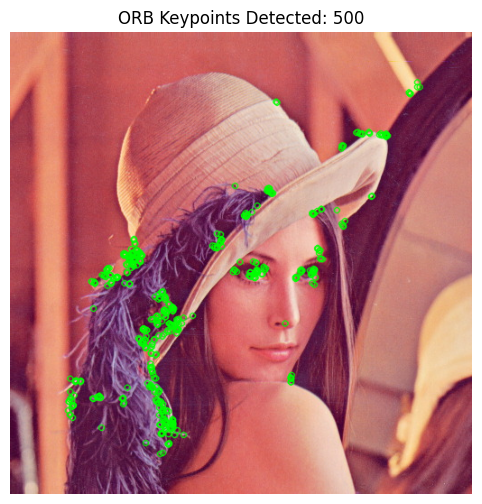

In [86]:
# =============================================================================
# 测试练习1：使用 ORB 检测关键点
# Test Exercise 1: Detect Keypoints using ORB
# =============================================================================

# 步骤1：创建最多检测500个特征点的 ORB 检测器
# Step 1: Create ORB detector with 500 features limit
orb = create_orb_detector(nfeatures=500)

# 步骤2：运行关键点检测
# Step 2: Run keypoint detection
kp, des, img_kp = detect_keypoints(IMAGE_PATH, orb)

# 步骤3：显示结果
# Step 3: Display result
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title(f"ORB Keypoints Detected: {len(kp)}")
plt.axis('off')
plt.show()

## **Exercise 2**

In [87]:
def match_images(image_path1, image_path2, orb_detector):
    """
    使用 ORB 和暴力匹配器匹配两张图像之间的特征。
    Match features between two images using ORB and BF Matcher.
    
    整体流程：
    Overall workflow:
    -------------------------------------------------------------------------
    图片1 → 检测关键点 → 计算描述符 ─┐
    Image1 → Detect keypoints → Compute descriptors ─┐
                                      ├→ 暴力匹配 → 找出对应点 → 画线连接
                                      ├→ BF Match → Find corresponding points → Draw lines
    图片2 → 检测关键点 → 计算描述符 ─┘
    Image2 → Detect keypoints → Compute descriptors ─┘
    -------------------------------------------------------------------------
    
    Args:
        image_path1: 第一张图像的路径 / Path to first image
        image_path2: 第二张图像的路径 / Path to second image
        orb_detector: ORB 检测器对象 / ORB detector object
    
    Returns:
        image_with_matches: 绘制了匹配线的组合图像
                            Combined image with match lines drawn
        num_matches: 匹配的特征点数量
                     Number of matched feature points
    """
    
    # 1. 检测两张图像中的关键点和描述符
    # 1. Detect keypoints and descriptors in both images
    # -------------------------------------------------------------------------
    # 对两张图片分别执行：检测关键点 + 计算描述符
    # Execute for both images: detect keypoints + compute descriptors
    # kp1, kp2: 关键点列表（位置信息）
    # kp1, kp2: keypoint lists (position info)
    # des1, des2: 描述符数组（特征信息）
    # des1, des2: descriptor arrays (feature info)
    # _: 忽略返回的可视化图像
    # _: ignore the returned visualization image
    # -------------------------------------------------------------------------
    kp1, des1, _ = detect_keypoints(image_path1, orb_detector)
    kp2, des2, _ = detect_keypoints(image_path2, orb_detector)

    # 2. 匹配两张图像的描述符
    # 2. Match descriptors between the two images
    # -------------------------------------------------------------------------
    # 调用 match_features() 进行暴力匹配
    # Call match_features() to perform brute-force matching
    # 返回按相似度排序的匹配列表
    # Returns match list sorted by similarity
    # -------------------------------------------------------------------------
    matches = match_features(des1, des2)

    # 3. 在组合图像上绘制匹配线
    # 3. Draw the matches on a combined image
    # -------------------------------------------------------------------------
    # drawMatches() 将两张图片并排放置，用线连接匹配的特征点
    # drawMatches() places two images side by side, draws lines connecting matched points
    # matches: 显示所有匹配
    # matches: show all matches
    # NOT_DRAW_SINGLE_POINTS: 不画没有匹配的点
    # NOT_DRAW_SINGLE_POINTS: don't draw unmatched points
    # -------------------------------------------------------------------------
    img1 = cv2.imread(image_path1)
    img2 = cv2.imread(image_path2)
    image_with_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, 
                                        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # 4. 返回绘制了匹配项的图像和匹配数量
    # 4. Return the image with matches drawn and number of matches
    return image_with_matches, len(matches)

Total matches found: 349


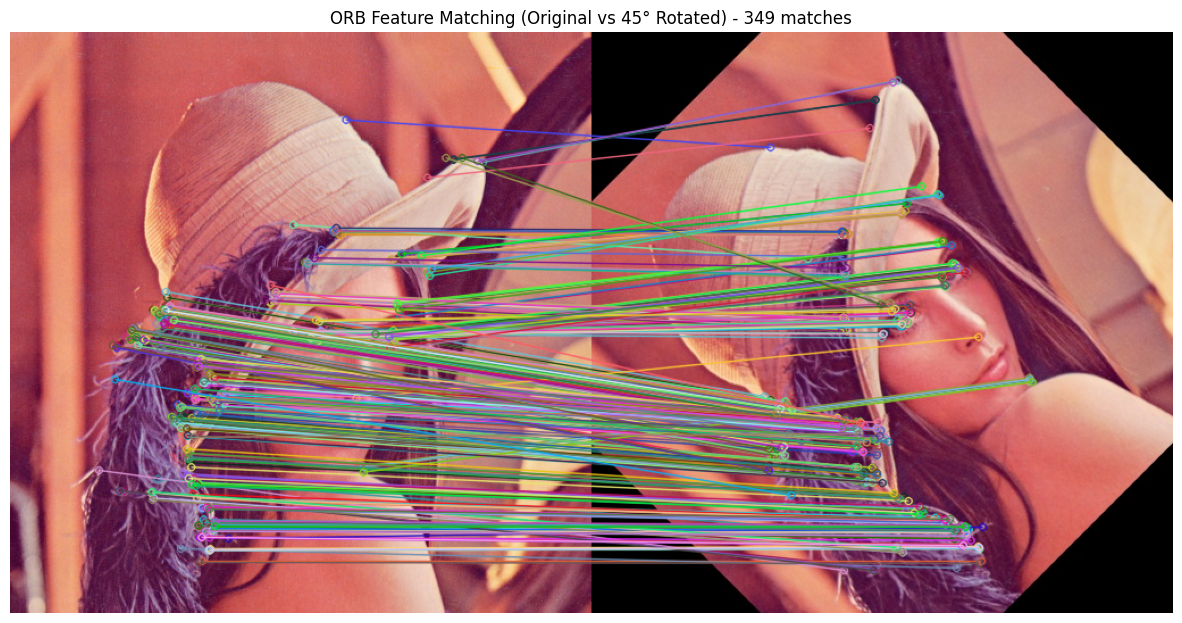

In [88]:
# =============================================================================
# 测试练习2：原图与旋转图之间的特征匹配
# Test Exercise 2: Feature Matching between Original and Rotated Images
# =============================================================================

# 步骤1：创建原图的旋转版本用于测试
# Step 1: Create a rotated version of the original image for testing
original_img = cv2.imread(IMAGE_PATH)
(h, w) = original_img.shape[:2]
center = (w // 2, h // 2)

# 绕中心旋转45度
# Rotate 45 degrees around center
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(original_img, M, (w, h))

# 保存旋转后的图像
# Save rotated image
ROTATED_IMAGE_PATH = "sample_image_rotated.jpg"
cv2.imwrite(ROTATED_IMAGE_PATH, rotated_img)

# 步骤2：运行特征匹配
# Step 2: Run feature matching
img_matching_result, num_matches = match_images(IMAGE_PATH, ROTATED_IMAGE_PATH, orb)

# 打印匹配数量
# Print number of matches
print(f"Total matches found: {num_matches}")

# 步骤3：显示结果
# Step 3: Display result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img_matching_result, cv2.COLOR_BGR2RGB))
plt.title(f"ORB Feature Matching (Original vs 45° Rotated) - {num_matches} matches")
plt.axis('off')
plt.show()

## **Exercise 3**

In [89]:
def compare_orb_performance(image_path, orb_detector):
    """
    比较不同图像状况下 ORB 特征检测的性能。
    Compare ORB feature detection under different image conditions.
    
    实验目的：
    Experiment purpose:
    -------------------------------------------------------------------------
    测试 ORB 在以下条件下的鲁棒性：
    Test ORB robustness under these conditions:
    - 模糊（Blur）: 图像不清晰时还能检测到多少特征？
    - Blur: How many features can be detected when image is unclear?
    - 噪声（Noise）: 图像有杂点时还能检测到多少特征？
    - Noise: How many features can be detected when image has noise?
    - 亮度（Brightness）: 图像过亮时还能检测到多少特征？
    - Brightness: How many features can be detected when image is too bright?
    
    这能帮助我们理解 ORB 的优缺点和适用场景
    This helps us understand ORB's strengths, weaknesses, and use cases
    -------------------------------------------------------------------------
    
    Args:
        image_path: 原始图像的路径 / Path to original image
        orb_detector: ORB 检测器对象 / ORB detector object
    
    Returns:
        comparison_results: 各条件下检测到的关键点数量（字典）
                            Number of keypoints detected under each condition (dict)
        altered_images: 各条件下绘制了关键点的图像列表
                        List of images with keypoints drawn for each condition
    """
    
    # 1. 加载图像并转换为灰度图
    # 1. Load image and convert to grayscale
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. 对图像应用不同的变换条件
    # 2. Apply different conditions to the image
    # -------------------------------------------------------------------------
    # 条件1: 模糊（Blurring）
    # Condition 1: Blurring
    # GaussianBlur 使用高斯核模糊图像，(7,7) 是核大小
    # GaussianBlur uses Gaussian kernel to blur image, (7,7) is kernel size
    # 模糊会使边缘变得不清晰，角点检测会更困难
    # Blur makes edges unclear, corner detection becomes harder
    # -------------------------------------------------------------------------
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    
    # -------------------------------------------------------------------------
    # 条件2: 噪声（Noise）
    # Condition 2: Noise
    # 添加高斯噪声（随机的亮度波动）
    # Add Gaussian noise (random brightness fluctuations)
    # 噪声会产生很多假的"角点"，干扰特征检测
    # Noise creates many false "corners", interferes with feature detection
    # -------------------------------------------------------------------------
    np.random.seed(42)  # 固定随机种子，保证结果可复现 / Fix random seed for reproducible results
    noise = np.random.normal(0, 25, gray.shape).astype(np.uint8)
    noisy = cv2.add(gray, noise)
    
    # -------------------------------------------------------------------------
    # 条件3: 亮度增强（Brightness）
    # Condition 3: Brightness enhancement
    # alpha=1.2 增加对比度，beta=50 增加亮度
    # alpha=1.2 increases contrast, beta=50 increases brightness
    # 过亮可能导致一些细节"过曝"丢失
    # Too bright may cause some details to be "overexposed" and lost
    # -------------------------------------------------------------------------
    bright = cv2.convertScaleAbs(gray, alpha=1.2, beta=50)

    # 3. 为每种条件检测特征
    # 3. Detect features for each condition
    # -------------------------------------------------------------------------
    # 分别对原图、模糊图、噪声图、高亮图进行特征检测
    # Detect features on original, blurred, noisy, and bright images separately
    # 比较检测到的关键点数量
    # Compare number of keypoints detected
    # -------------------------------------------------------------------------
    kp_ref, des_ref = orb_detector.detectAndCompute(gray, None)
    kp_blur, des_blur = orb_detector.detectAndCompute(blurred, None)
    kp_noise, des_noise = orb_detector.detectAndCompute(noisy, None)
    kp_bright, des_bright = orb_detector.detectAndCompute(bright, None)

    # 4. 在每张图上绘制关键点以便可视化
    # 4. Draw keypoints on each image for visualization
    img_ref_kp = cv2.drawKeypoints(gray, kp_ref, None, color=(0, 255, 0), flags=0)
    img_blur_kp = cv2.drawKeypoints(blurred, kp_blur, None, color=(0, 255, 0), flags=0)
    img_noise_kp = cv2.drawKeypoints(noisy, kp_noise, None, color=(0, 255, 0), flags=0)
    img_bright_kp = cv2.drawKeypoints(bright, kp_bright, None, color=(0, 255, 0), flags=0)

    # 5. 汇总比较结果
    # 5. Compile comparison results
    # -------------------------------------------------------------------------
    # 记录每种条件下检测到的关键点数量
    # Record number of keypoints detected under each condition
    # 数量越多，说明该条件对 ORB 影响越小
    # More keypoints = less impact from that condition on ORB
    # -------------------------------------------------------------------------
    comparison_results = {
        'Original': len(kp_ref),
        'Blurred': len(kp_blur),
        'Noisy': len(kp_noise),
        'Bright': len(kp_bright)
    }

    # 6. 返回结果和可视化图像
    # 6. Return results and visualizations
    return comparison_results, [img_ref_kp, img_blur_kp, img_noise_kp, img_bright_kp]

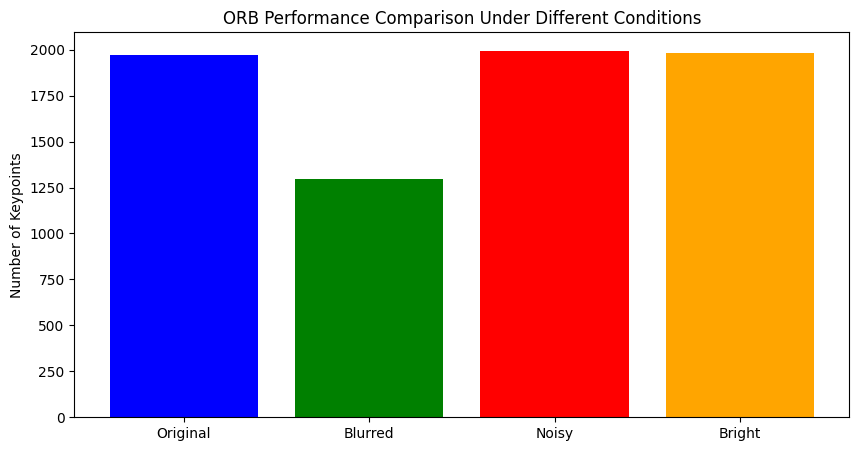

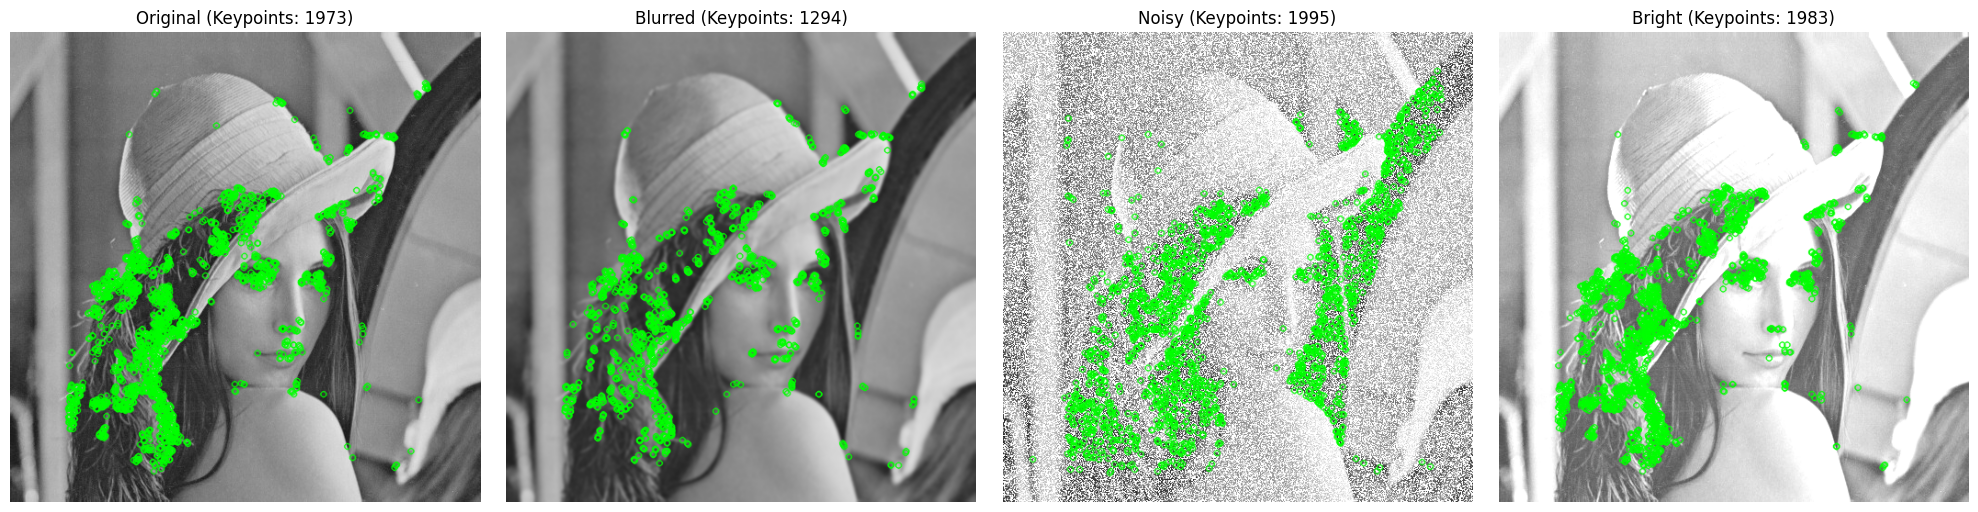

In [90]:
# =============================================================================
# 测试练习3：比较不同条件下 ORB 的性能表现
# Test Exercise 3: Compare ORB Performance Under Different Conditions
# =============================================================================

# 步骤1：创建更高特征数上限的检测器，以便更好地比较
# Step 1: Create detector with higher feature limit for better comparison
orb_comparison = create_orb_detector(nfeatures=2000)

# 步骤2：运行性能比较
# Step 2: Run performance comparison
results, altered_images = compare_orb_performance(IMAGE_PATH, orb_comparison)

# 步骤3：绘制柱状图总结
# Step 3: Plot bar chart summary
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'red', 'orange'])
plt.ylabel('Number of Keypoints')
plt.title('ORB Performance Comparison Under Different Conditions')
plt.show()

# 步骤4：绘制所有条件的视觉对比
# Step 4: Plot visual comparison of all conditions
titles = ['Original', 'Blurred', 'Noisy', 'Bright']
plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(cv2.cvtColor(altered_images[i], cv2.COLOR_BGR2RGB))
    plt.title(f"{titles[i]} (Keypoints: {results[titles[i]]})")
    plt.axis('off')
plt.tight_layout()
plt.show()